# Geophysical Inversion
## Homework 4
## Magnús Pálsson

### Problem 1

Consider an underdetermined problem in which each datum is the sum of three neighboring model parameters, that is, $d_i = m_{i-1}+m_i+m_{i+1}$ for $2\leq i \leq(M-1)$ with $M=100$. Compute and plot both the Dirichlet and Backus-Gilbert model resolution matrices.
Use the standard Backus-Gilbert weight function $w(i, j)=(i-j)^2$. Interpret the results

In [94]:
import numpy as np 
import matplotlib.pyplot as plt 
# ----------------
# Define Functions
# ----------------
def D_generalised_inverse(G):
    return(G.T.dot(np.linalg.inv(G.dot(G.T))))
        
def BG_generalised_inverse(G, data_size):
    Ginv = np.zeros((data_size, data_size-2))
    u = G.sum(axis=1).reshape(-1, 1)
    for k in np.arange(0,data_size-2):
        dist = np.ones(data_size)*(k+1) - np.arange(data_size)
        w = np.power(dist, 2).reshape(1,-1)
        # cursed broadcasting
        S = (G * w).dot(G.T)
        Sinv = np.linalg.inv(S)
        # MOAR CURSED BROADCASTING
        Ginv[k,:] = (u * Sinv).sum(axis=0) / ((u * Sinv) * u.T).sum()
    return Ginv
            


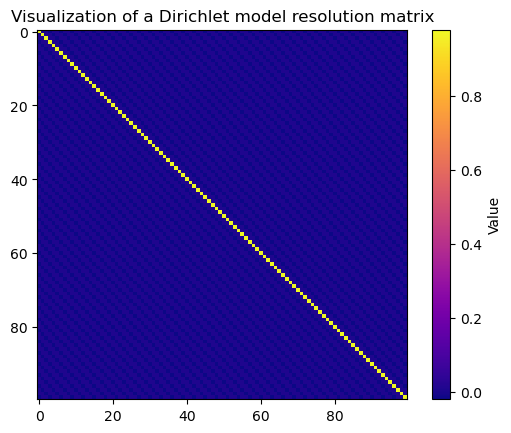

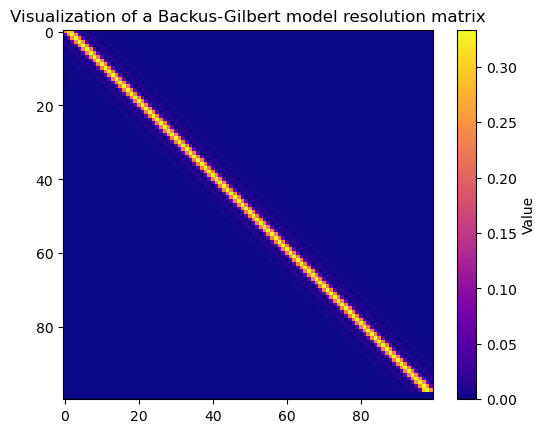

In [96]:

# ----------------
# Script
# ----------------
data_size = 100
# Create G by slicing a square diagonal matrix to shape
Temp = np.diag(np.ones(data_size)) + np.diag(np.ones(data_size-1),1) + np.diag(np.ones(data_size-2),2)
G = Temp[0:(data_size-2),:]

# Calculate and plot R for Diriclet spread
R = D_generalised_inverse(G).dot(G)
plt.imshow(R, cmap="plasma")
plt.colorbar(label='Value')
plt.title('Visualization of a Dirichlet model resolution matrix')
plt.show()

# Calculate and plot R for Backus-Gilbert spread with standard weight function w(i,j) = (i-j)**2
R = BG_generalised_inverse(G, data_size).dot(G)
plt.imshow(R, cmap="plasma")
plt.colorbar(label='Value')
plt.title('Visualization of a Backus-Gilbert model resolution matrix')
plt.show()


#### Interpretation

We see that the Dirichlet model resolution matrix has a clear narrow diagonal with faint bands radiating out from it at even intervals. The bands do not get fainter further from the diagonal. 

The Backus-Gilbert model resolution matrix however has a wider diagonal with some bands similar to the Dirichlet bands but they quicly fade as we move further from the diagonal.

This is what we expect, given the purpose of the Backus-Gilbert spread function.